# Mood-based-Dog-Face-Generation 🐶


This script automates the inference process by importing pre-trained weights into a newly initialized Generator network. By mapping these learned parameters to the model architecture, the script can synthesize dog facial expressions across all four targeted emotion classes (Angry, Happy, Relaxed, and Sad).

**Requirement:** Ensure the trained weights are saved as "generator.pth" in the root directory. The inference script depends on this file to correctly initialize the generative layers.

## Define Generator architecture

In [1]:
import torch
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self, noise_dim=100, num_classes=4):
        super().__init__()

        self.noise_dim = noise_dim
        self.num_classes = num_classes

        # ── Label embedding branch ─────────────────────────────
        # (batch,) → (batch, 100)
        self.label_emb = nn.Embedding(num_classes, 100)

        # (batch, 100) → (batch, 64)
        # reshape later: (batch, 64) → (batch, 1, 8, 8)
        self.label_block = nn.Sequential(
            nn.Linear(100, 8 * 8)
        )

        # ── Noise branch ───────────────────────────────────────
        # (batch, 100) → (batch, 256*8*8)
        self.noise_block = nn.Sequential(
            nn.Linear(noise_dim, 256 * 8 * 8),
            nn.LeakyReLU(0.2)
        )

        # ── Upsampling block 1 ─────────────────────────────────
        # 256 noise channels + 1 label channel = 257
        # (batch, 257, 8, 8) → (batch, 128, 16, 16)
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(257, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        # ── Upsampling block 2 ─────────────────────────────────
        # (batch, 128, 16, 16) → (batch, 64, 32, 32)
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2)
        )

        # ── Upsampling block 3 ─────────────────────────────────
        # (batch, 64, 32, 32) → (batch, 32, 64, 64)
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2)
        )

        # ── Output block ───────────────────────────────────────
        # (batch, 32, 64, 64) → (batch, 3, 64, 64)
        self.output_block = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        if labels.dtype == torch.float:
            labels = labels.to(torch.long)

        # label branch
        label = self.label_emb(labels)
        label = self.label_block(label)
        label = label.view(-1, 1, 8, 8)

        # noise branch
        gen = self.noise_block(noise)
        gen = gen.view(-1, 256, 8, 8)

        # merge label + noise
        x = torch.cat([gen, label], dim=1)

        # upsample to image
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        out = self.output_block(x)

        return out

## Import the model weight

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Generator().to(device)
model.load_state_dict(torch.load('generator.pth', map_location=device))
model.eval()

Generator(
  (label_emb): Embedding(4, 100)
  (label_block): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
  )
  (noise_block): Sequential(
    (0): Linear(in_features=100, out_features=16384, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (block1): Sequential(
    (0): ConvTranspose2d(257, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (block2): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (block3): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  

## Generate Image with the model

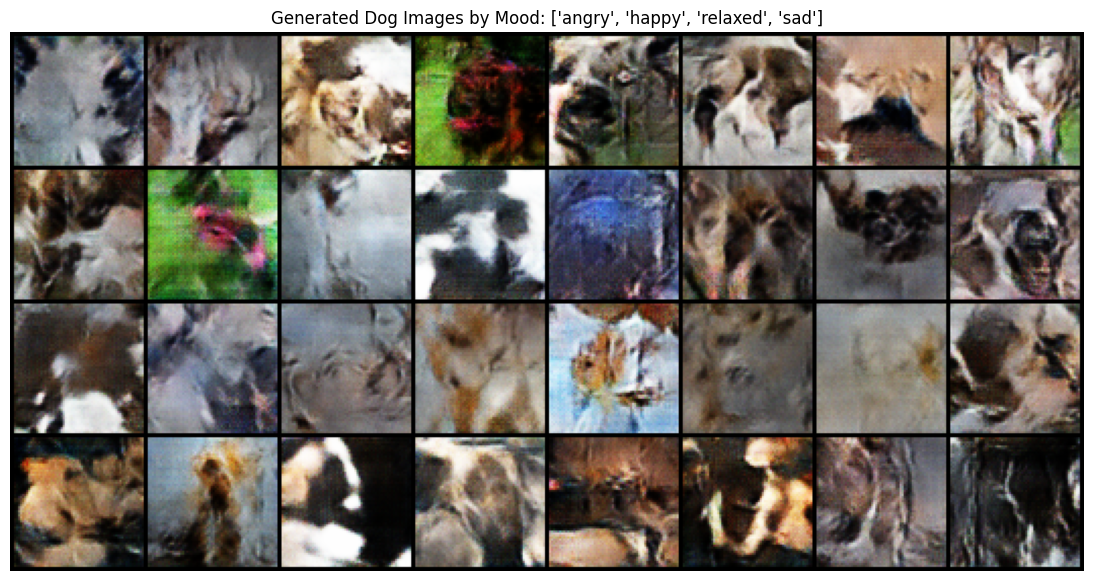

In [24]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


CLASS_NAMES = ['angry', 'happy', 'relaxed', 'sad']
samples_per_class = 8
noise_dim = 100
num_epochs = 100
num_classes = len(CLASS_NAMES)

# Re-instantiate the Generator model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Generator().to(device)
model.load_state_dict(torch.load('generator.pth', map_location=device)) # Commented out due to previous file issues
model.eval()

noise = torch.randn(num_classes * samples_per_class, noise_dim).to(device)
labels = torch.arange(num_classes).repeat_interleave(samples_per_class).to(device)

with torch.no_grad():
    generated = model(noise, labels)

# Convert from [-1, 1] to [0, 1]
generated = (generated + 1) / 2
generated = torch.clamp(generated, 0, 1)

grid = make_grid(generated, nrow=samples_per_class)

plt.figure(figsize=(14, 7))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title(f"Generated Dog Images by Mood: {CLASS_NAMES}")
plt.axis("off")
plt.show()